### Early Dysgraphia Screening from Handwriting — Potential Dysgraphia Handwriting Dataset (PDM)

**CRISP-DM phase:** Modeling (revised)

**Why this rewrite.** The previous version of this notebook trained on 249 full-page
`256x256` scans. That's a small dataset for a CNN, and a full-page image gives the model
plenty of shortcuts that have nothing to do with stroke structure — overall page layout,
how many lines someone wrote, margins, scan artifacts. This version **abandons that
pipeline entirely**. Instead, we cut each scan into individual word fragments with
OpenCV, which forces the model to learn from stroke-level structure,ie letter formation, spacing and pressure.
This notebook follows a strict five-step sequence:

1. **OpenCV extraction pipeline** — binarize each scan, strip out the ruled
   notebook lines, dilate, and contour-detect individual word fragments into a new
   `EXTRACTED_DATASET` directory. Every later step in this notebook, and every notebook
   after it, uses `EXTRACTED_DATASET`, not the original scans.
2. **Data loading & splitting** — load fragments as `(64, 128, 1)` tensors, stratified
   60/20/20 split, training-only rotation + translation augmentation.
3. **Custom Dysgraphia CNN** — a lightweight architecture built specifically for
   `(64, 128, 1)` fragments.
4. **Transfer learning** — MobileNetV2 adapted to accept the fragment shape.
5. **Evaluation** — final chosen model scored once on the untouched fragment-level test split.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!find /content/drive/MyDrive -iname "All.zip"

/content/drive/MyDrive/All.zip


In [5]:
!unzip -q "/content/drive/MyDrive/All.zip" -d /content/All
!ls /content/All

'DATASET DYSGRAPHIA HANDWRITING'


## 0. Setup and Imports

In [9]:
import os, random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, f1_score, recall_score, precision_score,
)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Define constants for the dataset and classes
CLASSES = ["Low Potential Dysgraphia", "Potential Dysgraphia"]
LABEL_MAP = {"Low Potential Dysgraphia": 0, "Potential Dysgraphia": 1}
POSITIVE_CLASS = "Potential Dysgraphia"

# Define paths for the dataset and extracted data
DATASET_ROOT = Path("/content/All/DATASET DYSGRAPHIA HANDWRITING")
EXTRACTED_ROOT = Path("EXTRACTED_DATASET")

# Error handling
assert DATASET_ROOT.exists(), ("Could not find the dataset root folder.")

## 1. OpenCV Extraction Pipeline

For each original scan we:

1. **Binarize** — threshold to a clean ink-vs-background mask (ink is white on black in
   this dataset, consistent with the quality check in notebook 02).
2. **Obliterate the ruled notebook lines** — long horizontal ruling lines are bright,
   like the ink, so a naive threshold keeps them. We isolate them with a morphological
   **opening** using a wide, short `(40, 1)` kernel (40 px wide, 1 px tall) — wide enough
   to only survive on long horizontal runs, not on individual letter strokes — then
   subtract that from the binary mask. What's left is handwriting with the ruling
   removed.
3. **Dilate to merge strokes into words** — a `(15, 5)` kernel pulls nearby
   letters within a word together into one connected blob, while mostly
   keeping separate words apart, since the horizontal reach (15 px) is deliberately
   bigger than the vertical reach (5 px).
4. **Contour detection** — `cv2.findContours` on the dilated mask gives one bounding box
   per word-sized blob. We crop each box **from the line-removed (non-dilated) mask**, so
   the dilation is only ever used to decide *where* to cut, not baked into the saved
   fragment itself.
5. **Filter and save** — contours below a minimum width/height/area are discarded as
   noise eg, stray dots, broken strokes, and everything else is saved into
   a png.


In [10]:
# Define image processing parameters for word fragment extraction
LINE_KERNEL_SIZE = (40, 1)     # isolates long horizontal ruling lines
DILATE_KERNEL_SIZE = (15, 5)  # merges letters into word-sized blobs before contouring

# Define minimum size thresholds for detected word fragments
MIN_FRAGMENT_W = 15
MIN_FRAGMENT_H = 10
MIN_FRAGMENT_AREA = 200

# Function to extract word fragments
def extract_word_fragments(gray_img):
    # Given a raw grayscale page (white ink on black background), return a list of (x, y, w, h, fragment_crop) for each detected word fragment.
    _, binary = cv2.threshold(gray_img, 30, 255, cv2.THRESH_BINARY)

    # isolate and remove the horizontal ruled lines
    line_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, LINE_KERNEL_SIZE)
    ruled_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, line_kernel)
    no_lines = cv2.subtract(binary, ruled_lines)

    # dilate to merge letters into word-sized blobs, purely to guide contour detection
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, DILATE_KERNEL_SIZE)
    dilated = cv2.dilate(no_lines, dilate_kernel, iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    fragments = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w < MIN_FRAGMENT_W or h < MIN_FRAGMENT_H or (w * h) < MIN_FRAGMENT_AREA:
            continue
        crop = no_lines[y:y + h, x:x + w]
        fragments.append((x, y, w, h, crop))

    # left-to-right, top-to-bottom reading order
    fragments.sort(key=lambda f: (f[1] // 40, f[0]))
    return fragments

In [11]:
# Function to build the extracted dataset
def build_extracted_dataset(dataset_root=DATASET_ROOT, extracted_root=EXTRACTED_ROOT):
    extracted_root.mkdir(exist_ok=True)
    manifest = []

    for cls in CLASSES:
        src_folder = dataset_root / cls
        dst_folder = extracted_root / cls
        dst_folder.mkdir(parents=True, exist_ok=True)
        # clear out fragments from any previous run before rebuilding
        for old in dst_folder.glob("*.png"):
            old.unlink()

        for fname in sorted(os.listdir(src_folder)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            path = src_folder / fname
            gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue

            fragments = extract_word_fragments(gray)
            stem = Path(fname).stem
            for i, (x, y, w, h, crop) in enumerate(fragments):
                out_name = f"{stem}_frag_{i:03d}.png"
                cv2.imwrite(str(dst_folder / out_name), crop)
                manifest.append({
                    "class": cls, "source_file": fname, "fragment_file": out_name,
                    "x": x, "y": y, "w": w, "h": h,
                })

    return pd.DataFrame(manifest)

extraction_manifest = build_extracted_dataset()
print("Fragments extracted:", len(extraction_manifest))
extraction_manifest.groupby("class").size()

Fragments extracted: 26684


,0
class,
Low Potential Dysgraphia,4714
Potential Dysgraphia,21970


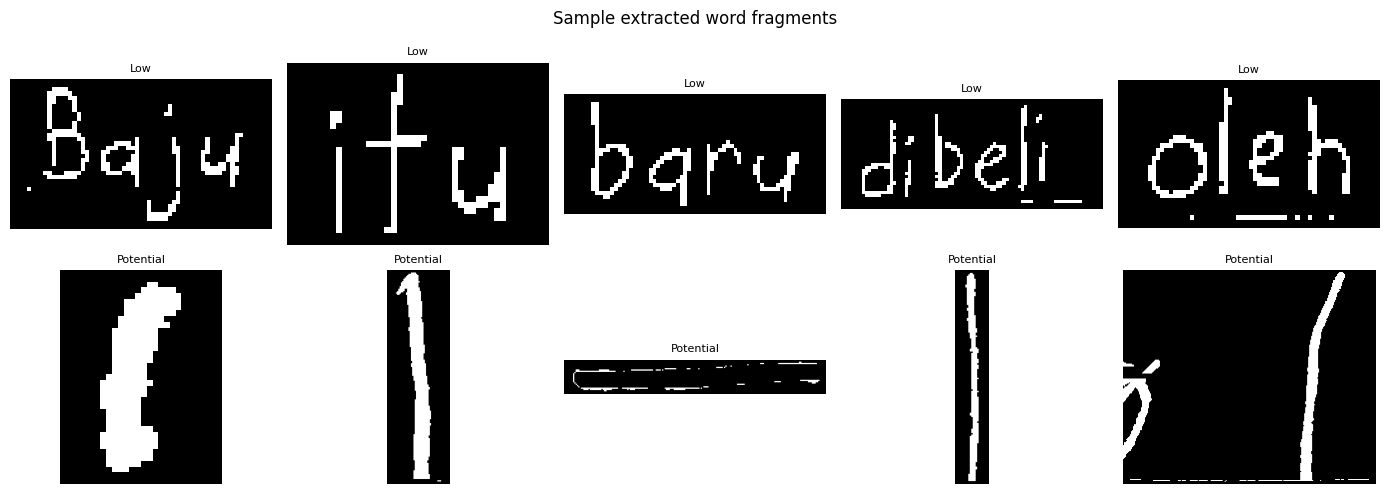

In [12]:
# visualize the extracted fragments
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for row, cls in enumerate(CLASSES):
    sample = extraction_manifest[extraction_manifest["class"] == cls].head(5)
    for col, (_, rec) in enumerate(sample.iterrows()):
        frag_path = EXTRACTED_ROOT / cls / rec["fragment_file"]
        img = cv2.imread(str(frag_path), cv2.IMREAD_GRAYSCALE)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls.split()[0], fontsize=8)
        axes[row, col].axis("off")
plt.suptitle("Sample extracted word fragments")
plt.tight_layout()
plt.show()

## 2. Data Loading & Splitting

Fragments are resized into a fixed `(64, 128)` — **height 64, width 128** — single
channel tensor, using the same scale-then-pad approach as the full-page pipeline in
notebooks 01–03, just re-targeted to the fragment shape. Padding uses black (0), matching
the fragment background.

We split **at the fragment level**, stratified 60/20/20 by class, same as the full-page
modeling notebook. Because many fragments come from the same source page, there is a real
risk of leakage if fragments from the same page end up split across train and test — a
model could partly learn to recognize *a specific child's page* rather than dysgraphia
in general.


In [13]:
FRAGMENT_SIZE = (128, 64)  # (width, height) fed into resize_and_pad -- matches (64,128,1) tensors

# resize and pad a fragment to the target size
def resize_and_pad_fragment(img, target_size=FRAGMENT_SIZE):
    h, w = img.shape
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = max(int(w * scale), 1), max(int(h * scale), 1)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_h, target_w), dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas

# normalize the pixel values to [0, 1] range
def normalize(img):
    return img.astype("float32") / 255.0

# loading a fragment from disk, resizing/padding, and normalizing it
def load_fragment(path, target_size=FRAGMENT_SIZE):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = resize_and_pad_fragment(img, target_size)
    img = normalize(img)
    return img

In [14]:
# build the fragment-level index directly from EXTRACTED_DATASET
frag_records = []
for cls in CLASSES:
    folder = EXTRACTED_ROOT / cls
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(".png"):
            source_page = fname.split("_frag_")[0]
            frag_records.append({
                "path": str(folder / fname), "class": cls, "label": LABEL_MAP[cls],
                "source_page": source_page,
            })

# create a DataFrame for the fragment index
frag_index = pd.DataFrame(frag_records)
print("Total fragments:", len(frag_index))
print(frag_index["class"].value_counts())
print("\nUnique source pages:", frag_index["source_page"].nunique())

Total fragments: 26683
class
Potential Dysgraphia        21969
Low Potential Dysgraphia     4714
Name: count, dtype: int64

Unique source pages: 1623


In [15]:
# Load all fragments and their labels into numpy arrays for model training
def load_fragments(df):
    X = np.stack([load_fragment(p) for p in df["path"]])
    X = X[..., np.newaxis]
    y = df["label"].to_numpy(dtype="float32")
    return X, y

X_all, y_all = load_fragments(frag_index)
print("X_all:", X_all.shape, "y_all:", y_all.shape)

X_all: (26683, 64, 128, 1) y_all: (26683,)


In [16]:
# train-test split
# 60 / 20 / 20 stratified split
train_idx, temp_idx = train_test_split(
    frag_index.index, test_size=0.4, stratify=frag_index["label"], random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=frag_index.loc[temp_idx, "label"], random_state=SEED
)

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val,   y_val   = X_all[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name}: n={len(y)}, Potential Dysgraphia={int(y.sum())} ({y.mean():.1%})")

class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("class_weight:", class_weight)

train: n=16009, Potential Dysgraphia=13181 (82.3%)
val: n=5337, Potential Dysgraphia=4394 (82.3%)
test: n=5337, Potential Dysgraphia=4394 (82.3%)
class_weight: {0: np.float64(2.8304455445544554), 1: np.float64(0.6072756240042485)}


In [17]:
# training-only augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05, fill_mode="constant", fill_value=0.0),
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08,
                              fill_mode="constant", fill_value=0.0),
], name="fragment_augmentation")

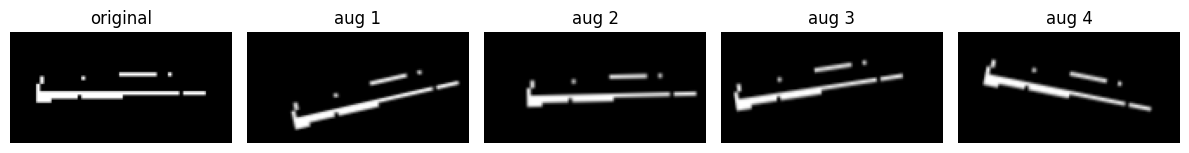

In [18]:
# visualization of a real fragment
sample_frag = X_train[0:1]
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(sample_frag[0, ..., 0], cmap="gray"); axes[0].set_title("original"); axes[0].axis("off")
for i in range(1, 5):
    aug = data_augmentation(sample_frag, training=True)
    axes[i].imshow(aug[0, ..., 0].numpy(), cmap="gray"); axes[i].set_title(f"aug {i}"); axes[i].axis("off")
plt.tight_layout()
plt.show()

## 3. The Custom Dysgraphia CNN

Built specifically for `(64, 128, 1)` fragments rather than reusing the full-page
architecture at a different input size. Three conv blocks with max pooling reduce
`64x128` down to a small spatial map, global average pooling collapses that to a feature
vector (no `Flatten` into a large dense stack — a wide dense layer on a small, easily
overfit dataset just re-introduces the risk we're trying to avoid by using fragments in
the first place), and dropout is set aggressively at **0.5** given how repetitive and
small individual word fragments are compared to full pages.


In [19]:
# Build the CNN model
def build_dysgraphia_cnn(input_shape=(64, 128, 1), dropout_rate=0.5, learning_rate=1e-3):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    # block 1
    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # block 2
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # block 3
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # straight from pooled features to the output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="dysgraphia_fragment_cnn")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model

dysgraphia_cnn = build_dysgraphia_cnn()
dysgraphia_cnn.summary()

Model: "dysgraphia_fragment_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fragment_augmentation           │ (None, 64, 128, 1)     │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 128, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,361 (91.25 KB)

 Trainable params: 23,361 (91.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the CNN
cnn_callbacks = [
    callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8,
                             restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5,
                                 patience=4, min_lr=1e-6),
]

cnn_history = dysgraphia_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    class_weight=class_weight,
    callbacks=cnn_callbacks,
    verbose=2,
)

Epoch 1/60
501/501 - 14s - 28ms/step - accuracy: 0.6278 - auc: 0.6560 - loss: 0.6521 - precision: 0.8777 - recall: 0.6367 - val_accuracy: 0.3925 - val_auc: 0.7251 - val_loss: 0.9464 - val_precision: 0.9150 - val_recall: 0.2890 - learning_rate: 0.0010
Epoch 2/60
501/501 - 5s - 11ms/step - accuracy: 0.7139 - auc: 0.7082 - loss: 0.6156 - precision: 0.8954 - recall: 0.7389 - val_accuracy: 0.5059 - val_auc: 0.7592 - val_loss: 0.8408 - val_precision: 0.9142 - val_recall: 0.4413 - learning_rate: 0.0010
Epoch 3/60
501/501 - 6s - 12ms/step - accuracy: 0.7761 - auc: 0.7373 - loss: 0.5868 - precision: 0.8978 - recall: 0.8216 - val_accuracy: 0.5846 - val_auc: 0.7756 - val_loss: 0.8007 - val_precision: 0.9195 - val_recall: 0.5430 - learning_rate: 0.0010
Epoch 4/60
501/501 - 5s - 11ms/step - accuracy: 0.7912 - auc: 0.7695 - loss: 0.5650 - precision: 0.8956 - recall: 0.8449 - val_accuracy: 0.5979 - val_auc: 0.7875 - val_loss: 0.7698 - val_precision: 0.9226 - val_recall: 0.5585 - learning_rate: 0.0010

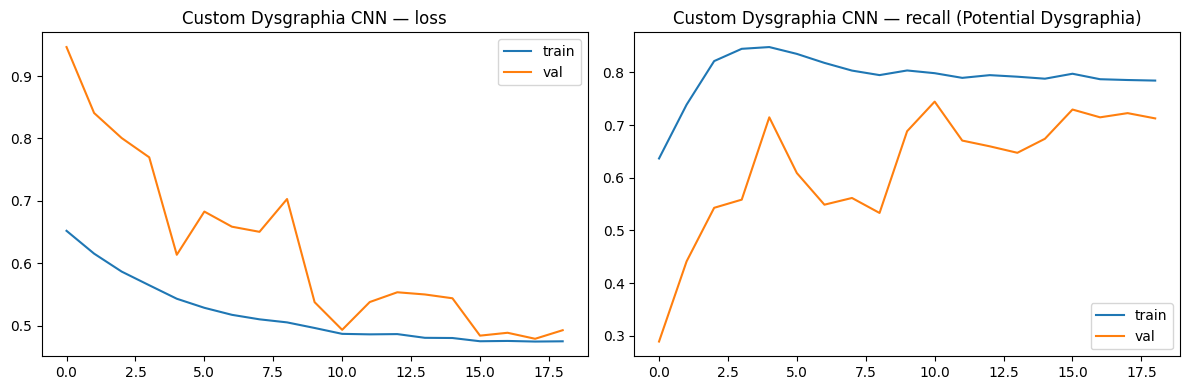

Custom CNN — validation
                      precision    recall  f1-score   support

       Low Potential       0.39      0.75      0.51       943
Potential Dysgraphia       0.93      0.74      0.83      4394

            accuracy                           0.75      5337
           macro avg       0.66      0.75      0.67      5337
        weighted avg       0.84      0.75      0.77      5337

ROC AUC: 0.852


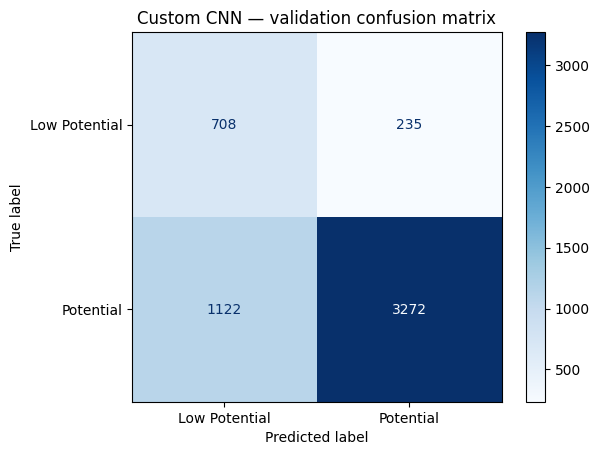

{'recall_potential': 0.7446517979062358,
 'precision_potential': 0.9329911605360707,
 'f1_potential': 0.8282495886596634,
 'roc_auc': np.float64(0.8522789198227024)}

In [21]:
# Evaluate the CNN
def plot_history(history, title):
    hist = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["loss"], label="train")
    ax[0].plot(hist["val_loss"], label="val")
    ax[0].set_title(f"{title} — loss"); ax[0].legend()
    ax[1].plot(hist["recall"], label="train")
    ax[1].plot(hist["val_recall"], label="val")
    ax[1].set_title(f"{title} — recall (Potential Dysgraphia)"); ax[1].legend()
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X, y, split_name="validation"):
    probs = model.predict(X, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)

    print(f"{split_name}")
    print(classification_report(y, preds, target_names=["Low Potential", "Potential Dysgraphia"]))
    print("ROC AUC:", round(roc_auc_score(y, probs), 3))

    cm = confusion_matrix(y, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Low Potential", "Potential"]).plot(cmap="Blues")
    plt.title(f"{split_name} confusion matrix")
    plt.show()

    return {
        "recall_potential": recall_score(y, preds, pos_label=1),
        "precision_potential": precision_score(y, preds, pos_label=1),
        "f1_potential": f1_score(y, preds, pos_label=1),
        "roc_auc": roc_auc_score(y, probs),
    }

plot_history(cnn_history, "Custom Dysgraphia CNN")
cnn_val_metrics = evaluate_model(dysgraphia_cnn, X_val, y_val, "Custom CNN — validation")
cnn_val_metrics

## 4. Transfer Learning

The custom CNN above is the primary model for this fragment-based approach — it's built
for the fragment shape and has far fewer parameters to overfit with. MobileNetV2 is kept
here and adjusted to accept fragments rather than full pages:
fragments are resized from `(64, 128, 1)` up to `(224, 224)` and the single grayscale
channel is duplicated into 3 channels **inside the model graph**, exactly as before, so
`X_all` stays a single reusable array. Only the frozen-backbone stage is trained here.


In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

BACKBONE_INPUT_SIZE = (224, 224)

# Build the transfer learning model using MobileNetV2
def build_transfer_model(input_shape=(64, 128, 1), dropout_rate=0.5,
                          learning_rate=1e-3, dense_units=32):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Resizing(*BACKBONE_INPUT_SIZE)(x)          # 64x128 -> 224x224
    x = layers.Concatenate(axis=-1)([x, x, x])             # 1 channel -> 3 channels
    x = layers.Rescaling(255.0)(x)                          # undo load_fragment's /255
    x = layers.Lambda(mobilenet_preprocess, name="mobilenet_preprocess")(x)

    base_model = MobileNetV2(input_shape=(*BACKBONE_INPUT_SIZE, 3),
                              include_top=False, weights="imagenet", pooling="avg")
    base_model.trainable = False  # frozen

    x = base_model(x, training=False)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="transfer_mobilenetv2_fragments")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model, base_model

transfer_model, backbone = build_transfer_model()
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "transfer_mobilenetv2_fragments"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 128,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fragment_augmentat… │ (None, 64, 128,   │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ fragment_augment… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ resizing[0][0],   │
│ (Concatenate)       │ 3)                │            │ resizing[0][0],   │
│                     │                   │            │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ concatenate[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_preproce… │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1280)      │  2,257,984 │ mobilenet_prepro… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │     40,992 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 41,025 (160.25 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
501/501 - 42s - 83ms/step - accuracy: 0.6902 - auc: 0.7788 - loss: 0.5668 - precision: 0.9195 - recall: 0.6836 - val_accuracy: 0.6202 - val_auc: 0.8664 - val_loss: 0.5604 - val_precision: 0.9747 - val_recall: 0.5530 - learning_rate: 0.0010
Epoch 2/30
501/501 - 34s - 67ms/step - accuracy: 0.7203 - auc: 0.8334 - loss: 0.5009 - precision: 0.9386 - recall: 0.7065 - val_accuracy: 0.6743 - val_auc: 0.8738 - val_loss: 0.5271 - val_precision: 0.9660 - val_recall: 0.6265 - learning_rate: 0.0010
Epoch 3/30
501/501 - 41s - 81ms/step - accuracy: 0.7270 - auc: 0.8404 - loss: 0.4939 - precision: 0.9424 - recall: 0.7119 - val_accuracy: 0.6609 - val_auc: 0.8872 - val_loss: 0.5262 - val_precision: 0.9771 - val_recall: 0.6022 - learning_rate: 0.0010
Epoch 4/30
501/501 - 34s - 67ms/step - accuracy: 0.7463 - auc: 0.8541 - loss: 0.4753 - precision: 0.9434 - recall: 0.7361 - val_accuracy: 0.6783 - val_auc: 0.8887 - val_loss: 0.5198 - val_precision: 0.9735 - val_recall: 0.6263 - learning_rate: 0.0

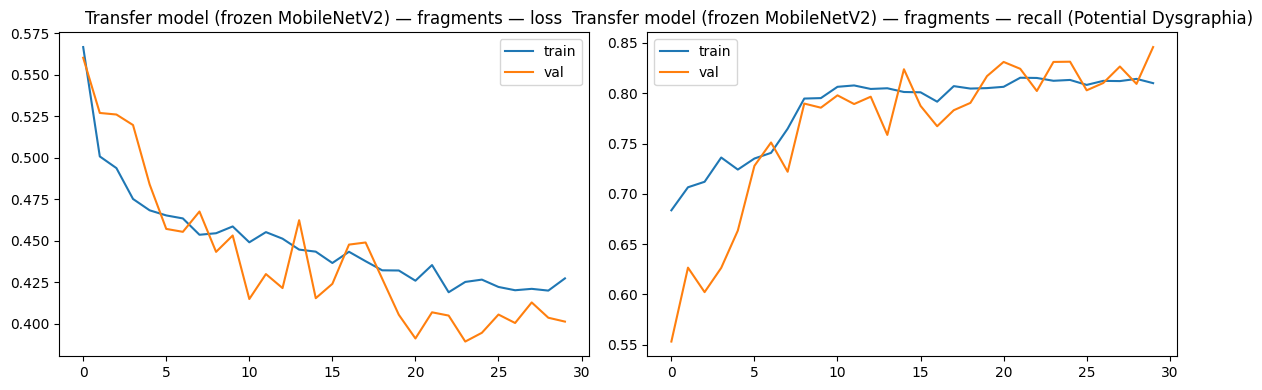

Transfer model — validation
                      precision    recall  f1-score   support

       Low Potential       0.53      0.81      0.64       943
Potential Dysgraphia       0.95      0.85      0.90      4394

            accuracy                           0.84      5337
           macro avg       0.74      0.83      0.77      5337
        weighted avg       0.88      0.84      0.85      5337

ROC AUC: 0.916


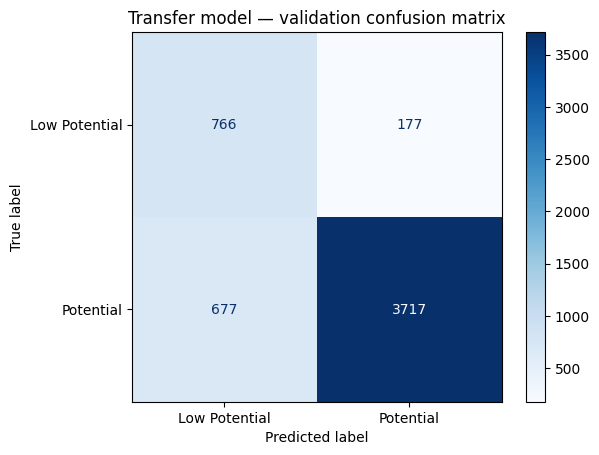

{'recall_potential': 0.8459262630860264,
 'precision_potential': 0.9545454545454546,
 'f1_potential': 0.8969594594594594,
 'roc_auc': np.float64(0.9163151960327662)}

In [23]:
# Train the transfer learning model
transfer_callbacks = [
    callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8,
                             restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5,
                                 patience=4, min_lr=1e-6),
]

transfer_history = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight,
    callbacks=transfer_callbacks,
    verbose=2,
)
plot_history(transfer_history, "Transfer model (frozen MobileNetV2) — fragments")
transfer_val_metrics = evaluate_model(transfer_model, X_val, y_val, "Transfer model — validation")
transfer_val_metrics

## 5. Evaluation

Comparing validation recall on the Potential Dysgraphia class decides which model goes
forward to the untouched test split — the same priority rule used throughout this
project: missing an at-risk fragment is the costlier mistake, so it drives model
selection, not overall accuracy.


In [24]:
# Compare the two models on the validation set
candidates = {
    "custom_cnn": (dysgraphia_cnn, cnn_val_metrics),
    "transfer_mobilenetv2": (transfer_model, transfer_val_metrics),
}

comparison_df = pd.DataFrame({
    name: metrics for name, (_, metrics) in candidates.items()
}).T
comparison_df

,recall_potential,precision_potential,f1_potential,roc_auc
custom_cnn,0.744652,0.932991,0.828250,0.852279
transfer_mobilenetv2,0.845926,0.954545,0.896959,0.916315


In [25]:
# Select the best model based on recall for the positive class
best_name = comparison_df["recall_potential"].idxmax()
final_model, _ = candidates[best_name]
print(f"Selected model for final test evaluation: {best_name}")

Selected model for final test evaluation: transfer_mobilenetv2


Final model (transfer_mobilenetv2) — TEST (final check)
                      precision    recall  f1-score   support

       Low Potential       0.53      0.83      0.65       943
Potential Dysgraphia       0.96      0.85      0.90      4394

            accuracy                           0.84      5337
           macro avg       0.75      0.84      0.77      5337
        weighted avg       0.88      0.84      0.85      5337

ROC AUC: 0.923


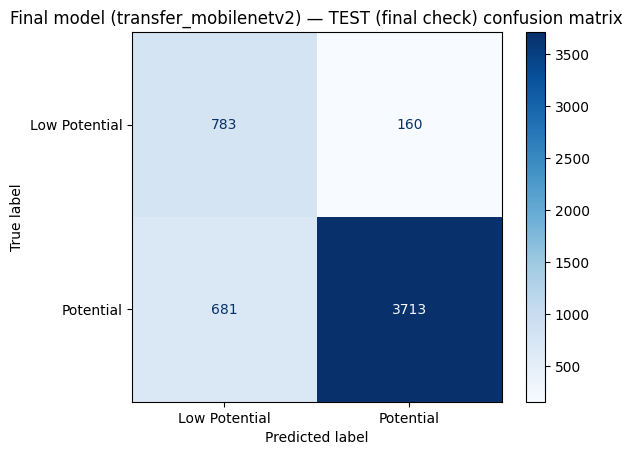

{'recall_potential': 0.8450159308147474,
 'precision_potential': 0.9586883552801446,
 'f1_potential': 0.898270231039071,
 'roc_auc': np.float64(0.9227338590992922)}

In [26]:
# Evaluate the selected model on the test set
final_test_metrics = evaluate_model(final_model, X_test, y_test,
                                     f"Final model ({best_name}) — TEST (final check)")
final_test_metrics

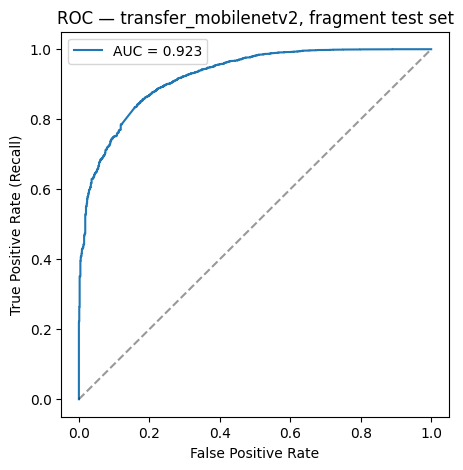

In [27]:
# Visualize the ROC curve for the final model on the test set
probs_test = final_model.predict(X_test, verbose=0).ravel()
fpr, tpr, _ = roc_curve(y_test, probs_test)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, probs_test):.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title(f"ROC — {best_name}, fragment test set")
plt.legend()
plt.show()

In [28]:
# Save the final model
final_model.save(f"dysgraphia_fragment_{best_name}.keras")
print(f"Saved final model to dysgraphia_fragment_{best_name}.keras")

Saved final model to dysgraphia_fragment_transfer_mobilenetv2.keras


## Summary

- **Step 1** replaced full-page scans with an OpenCV extraction pipeline: binarize →
  strip ruled lines with a `(40, 1)` morphological opening → dilate with `(15, 5)` to
  merge letters into words → contour-detect and crop → save into `EXTRACTED_DATASET`.
  Everything downstream uses only that directory.
- **Step 2** loads fragments as `(64, 128, 1)` tensors and applies a stratified 60/20/20
  split with training-only rotation + translation augmentation, tuned for the chaotic
  angles typical of dysgraphic writing. The **page-level leakage caveat** noted above is
  the main open item before trusting these numbers as a generalization claim.
- **Step 3** is the primary model: a lightweight custom CNN built for the fragment shape,
  three conv/pool blocks, no heavy dense stack, dropout at 0.5, early stopping on
  `val_recall`.
- **Step 4** is an optional comparison: MobileNetV2 adapted to fragments via in-graph
  resizing and channel duplication, frozen backbone only.
- **Step 5** picks whichever candidate has the higher validation recall on Potential
  Dysgraphia and scores it exactly once on the held-out fragment-level test split.
